A carregar o dataset do Titanic...


,survived,pclass,age,sibsp,parch,fare,sex,embarked
0,0,3,22.0,1,0,7.2500,male,S
1,1,1,38.0,1,0,71.2833,female,C
2,1,3,26.0,0,0,7.9250,female,S
3,1,1,35.0,1,0,53.1000,female,S
4,0,3,35.0,0,0,8.0500,male,S
5,0,3,NaN,0,0,8.4583,male,Q
6,0,1,54.0,0,0,51.8625,male,S
7,0,3,2.0,3,1,21.0750,male,S
8,1,3,27.0,0,2,11.1333,female,S
9,1,2,14.0,1,0,30.0708,female,C


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   age       714 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
 6   sex       891 non-null    object 
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


None

,count
sex,
male,577
female,314


Base pronta com 712 passageiros avaliados.



,count
survived,
0,424
1,288


A processar as regras da Árvore de Decisão...

Relatório de Sobrevivência (0 = Não Sobreviveu, 1 = Sobreviveu):
              precision    recall  f1-score   support

           0       0.88      0.76      0.82        85
           1       0.71      0.84      0.77        58

    accuracy                           0.80       143
   macro avg       0.79      0.80      0.79       143
weighted avg       0.81      0.80      0.80       143



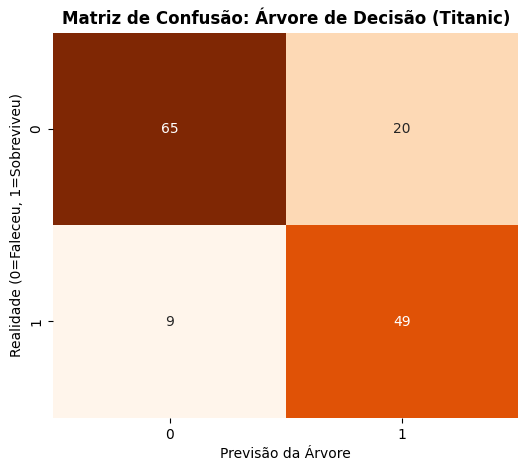

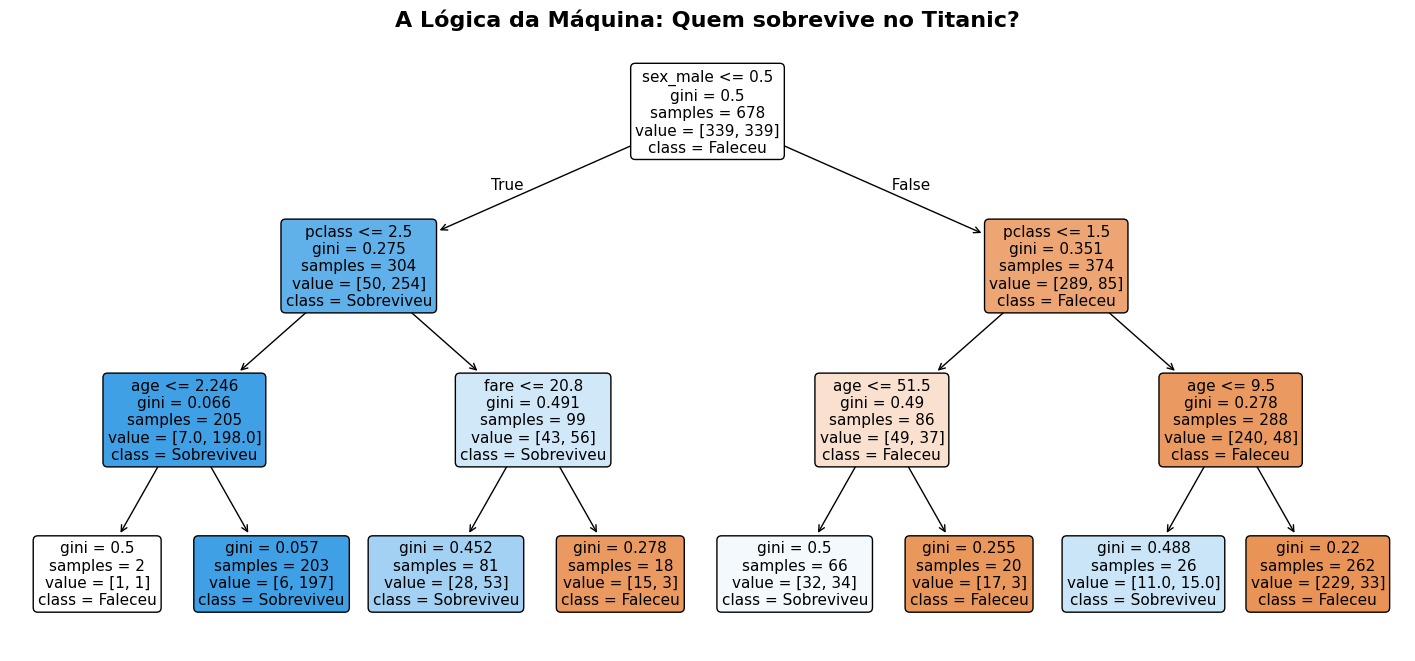

In [ ]:
# ==============================================================================
# LABORATÓRIO: ÁRVORE DE DECISÃO - SOBREVIVÊNCIA NO TITANIC (DADOS REAIS)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

print("A carregar o dataset do Titanic...")

# 1. Carregar os dados diretamente da biblioteca Seaborn
titanic = sns.load_dataset('titanic')

# Selecionar apenas algumas colunas para facilitar a visualização da árvore
colunas_selecionadas = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']
df = titanic[colunas_selecionadas].copy()

display(df.head(10))
display(df.info())

display(df['sex'].value_counts())
# 2. Pré-Processamento Rápido (Revisão das aulas anteriores)
df.dropna(inplace=True) # Remover passageiros sem idade registada
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True, dtype=int)

# Separar Features (X) e Target (y)
X = df.drop(columns=['survived'])
y = df['survived']

print(f"Base pronta com {X.shape[0]} passageiros avaliados.\n")

display(y.value_counts())

# 3. Separação Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# NOTA: A Árvore de Decisão NÃO necessita de StandardScaler. Lida bem com Idade e Tarifa misturadas.

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Treinamento da Árvore de Decisão
print("A processar as regras da Árvore de Decisão...")
arvore = DecisionTreeClassifier(
    max_depth=3,            # Profundidade máxima de 3 para não gerar uma árvore ilegível
    random_state=42,
    criterion='gini' #entropy
)
arvore.fit(X_train_res, y_train_res)

# 5. Previsões
previsoes_arvore = arvore.predict(X_test)

# 6. Avaliação
print("\nRelatório de Sobrevivência (0 = Não Sobreviveu, 1 = Sobreviveu):")
print(classification_report(y_test, previsoes_arvore))

# 7. Matriz de Confusão Visual
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, previsoes_arvore), annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Matriz de Confusão: Árvore de Decisão (Titanic)', fontweight='bold')
plt.ylabel('Realidade (0=Faleceu, 1=Sobreviveu)')
plt.xlabel('Previsão da Árvore')
plt.show()

# 8. A CAIXA BRANCA: Desenhar as regras matemáticas do modelo
plt.figure(figsize=(18, 8))
plot_tree(
    arvore,
    feature_names=X.columns,
    class_names=['Faleceu', 'Sobreviveu'],
    filled=True,         # Colore as caixinhas (laranja para óbitos, azul para sobreviventes)
    rounded=True,
    fontsize=11
)
plt.title("A Lógica da Máquina: Quem sobrevive no Titanic?", fontsize=16, fontweight='bold')
plt.show()


Importância das Features no Modelo:


,Feature,Importance
1,sex,0.606278
0,pclass,0.253754
2,age,0.105010
3,fare,0.034958


/tmp/ipykernel_8103/181910784.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


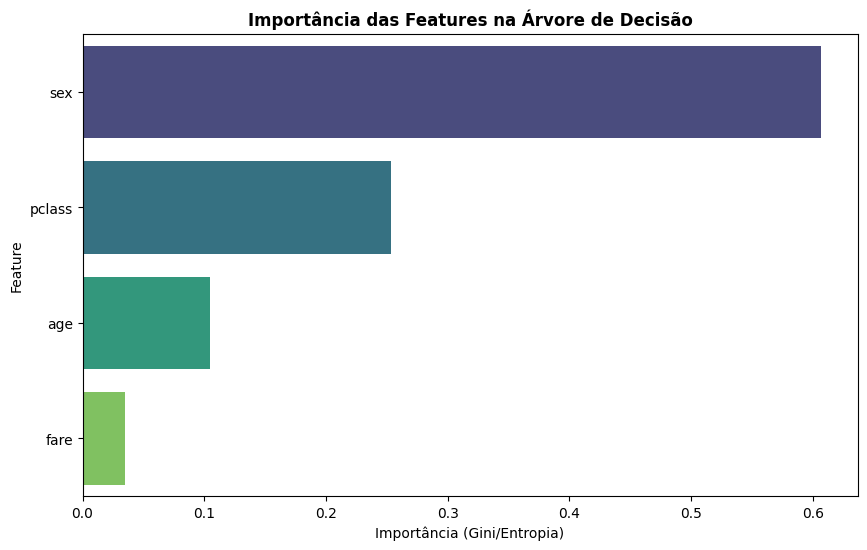

In [ ]:
# 9. Feature Importance
# Exibir a importância de cada "feature" (característica) no modelo.
# Isso nos ajuda a entender quais fatores a árvore de decisão considerou mais relevantes para prever a sobrevivência.

importances = arvore.feature_importances_
feature_names = X.columns

# Criar um DataFrame para melhor visualização
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nImportância das Features no Modelo:")
display(feature_importance_df)

# Visualizar a importância das features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importância das Features na Árvore de Decisão', fontweight='bold')
plt.xlabel('Importância (Gini/Entropia)')
plt.ylabel('Feature')
plt.show()